In [155]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [156]:
import numpy as np
import networkx as nx
import scipy
import matplotlib.pyplot as plt
import matplotlib as mpl
from dataclasses import dataclass, field
from typing import Optional

from functions import *

In [157]:
def jacobian(m, gamma, L):

    N = L.shape[0]
    size = 2*N
    J = np.zeros((size, size), dtype=float)

    for n in range(N):
        J[n, N+n] = 1
    
    for n1 in range(N):
        for n2 in range(N):
            J[N+n1, n2] = -1/m[n1] * L[n1, n2]

    for n in range(N):
        J[N+n, N+n] = -gamma[n] / m[n]
            
    return J

In [158]:
def mixed_condition(gamma, m, gamma_m_ratio, phi2, sigma2_max):

    omega_c = gamma_m_ratio * np.tan(np.pi/2 - phi2)

    sigma1_max = np.max(1 / np.sqrt(gamma**2 + (m * omega_c)**2))

    cond = (1/omega_c) * sigma1_max * sigma2_max < 1

    return cond

In [159]:
@dataclass
class ResultsSecond:
    alphas: list = field(default_factory=list)
    phi_L: list = field(default_factory=list)
    phi_rho0: list = field(default_factory=list)
    phi_rho1: list = field(default_factory=list)
    phi_rho2: list = field(default_factory=list)
    phi_zeta: list = field(default_factory=list)
    skar: list = field(default_factory=list)

    J_alpha = None
    phi_L_alpha = None
    phi_rho0_alpha = None
    phi_rho1_alpha = None
    phi_rho2_alpha = None
    phi_zeta_alpha = None
    skar_alpha = None
    lambda2_L0 = None
    lambda2_L0n = None

In [160]:
def compute_second(G, N, alphas, seed=12):
    rng = np.random.default_rng(seed)
    res = ResultsSecond()

    A_0 = nx.to_numpy_array(G)
    
    # Symmetric part
    w_min = 0.5
    w_max = 1.5
    W = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            undirect = rng.uniform(w_min, w_max)
            W[i, j] = undirect
            W[j, i] = undirect

    # Antisymmetric part
    Delta = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            direct = rng.choice([-1, 1])
            wdirect = rng.uniform(w_min, w_max)
            Delta[i, j] = direct * wdirect
            Delta[j, i] = -direct * wdirect

    # Topology
    d_0 = A_0.sum(axis=1)
    L_0 = np.diag(d_0) - A_0
    L_0_norm = np.diag(d_0**(-0.5)) @ L_0 @ np.diag(d_0**(-0.5))
    res.lambda2_L0n =  np.real(scipy.linalg.eigh(L_0_norm, eigvals_only=True, subset_by_index=[1, 1]))[0]
    res.lambda2_L0 =  np.real(scipy.linalg.eigh(L_0, eigvals_only=True, subset_by_index=[1, 1]))[0]
    max_deg = max(dict(G.degree()).values())
    mean_deg = sum(dict(G.degree()).values()) / G.number_of_nodes()

    # Nodes
    gamma_m_ratio = 2 * np.sqrt(mean_deg)
    m_min, m_max = 0.5, 1.5
    m = rng.uniform(m_min, m_max, size=N)
    gamma = gamma_m_ratio * m

    res.alphas.append(0.0)
    res.phi_L.append(0.0)
    res.phi_rho0.append(0.0)
    res.phi_rho1.append(0.0)
    res.phi_rho2.append(0.0)
    res.phi_zeta.append(0.0)

    for i in range(1, len(alphas)):
        alpha_prev = alphas[i - 1]
        alpha = alphas[i]
        res.alphas.append(alpha)

        # Laplacian
        A = W + alpha * Delta
        A[~A_0.astype(bool)] = 0
        D = np.diag(A.sum(axis=1))
        L = D - A

        # Laplacian norm
        L_norm = scipy.linalg.svdvals(L)[0]
        edge_gains = np.sqrt(2 * (A**2 + A.T**2)) 
        np.fill_diagonal(edge_gains, 0.0)
        L_norm_approx = edge_gains.max() * max_deg
        dout_din = (A.sum(axis=1) - A.sum(axis=0))

        # Jacobian max eigenvalue
        J = jacobian(m, gamma, L)
        eigvals_J = np.real(scipy.linalg.eigvals(J))
        lambda_J = np.max(np.real(eigvals_J))
        if lambda_J > 1e-10: 
            res.J_alpha = alpha_prev

        # Undirected part
        A_plus = 0.5 * (A + A.T)
        L_plus = np.diag(A_plus.sum(axis=1)) - A_plus
        L_plus_r = reduce(L_plus)
    
        # Directed part
        A_minus = 0.5 * (A - A.T)
        L_minus = np.diag(A_minus.sum(axis=1)) - A_minus
        L_minus_r = reduce(L_minus)

        # phi L
        if res.phi_L_alpha == None:
            xi0 = compute_xi0(L_plus_r, L_minus_r)
            if xi0 > -1:
                _, phi2 = julia_phi(reduce(L))
                res.phi_L.append(phi2)
                cond = mixed_condition(gamma, m, gamma_m_ratio, phi2, sigma2_max=L_norm) 
                if not cond: 
                    res.phi_L_alpha = alpha_prev
            else: 
                res.phi_L.append(np.nan)
                res.phi_L_alpha = alpha_prev
        else: 
            res.phi_L.append(np.nan)

        # # zeta
        # if res.phi_zeta_alpha is None:
        #     A_plus_min = np.min(A_plus[A_plus != 0])
        #     real_margin = (A_plus_min * res.lambda2_L0) + min(0.5*dout_din)
        #     if real_margin > 0: 
        #         phi2 = np.arctan(max(np.abs(A_minus).sum(axis=1)) / (real_margin))
        #         res.phi_zeta.append(phi2)
        #         cond = mixed_condition(gamma, m, gamma_m_ratio, phi2, sigma2_max=L_norm_approx) 
        #         if not cond: 
        #             res.phi_zeta_alpha = alpha_prev
        #     else: 
        #         res.phi_zeta.append(np.nan)
        #         res.phi_zeta_alpha = alpha_prev
        # else: 
        #     res.phi_zeta.append(np.nan)

        # rho0
        if res.phi_rho0_alpha is None:
            rho0 = compute_rho0(L_plus_r, L_minus_r)
            if rho0 < 1:
                phi2 = np.arcsin(rho0)
                res.phi_rho0.append(phi2)
                cond = mixed_condition(gamma, m, gamma_m_ratio, phi2, sigma2_max=L_norm) 
                if not cond: 
                    res.phi_rho0_alpha = alpha_prev
            else: 
                res.phi_rho0.append(np.nan)
                res.phi_rho0_alpha = alpha_prev
        else: 
            res.phi_rho0.append(np.nan)
        
        # rho1
        if res.phi_rho1_alpha is None:
            rho1 = compute_rho1(A_plus, A_minus, res.lambda2_L0)
            if rho1 < 1:
                phi2 = np.arcsin(rho1)
                res.phi_rho1.append(phi2)
                cond = mixed_condition(gamma, m, gamma_m_ratio, phi2, sigma2_max=L_norm_approx) 
                if not cond: 
                    res.phi_rho1_alpha = alpha_prev
            else: 
                res.phi_rho1.append(np.nan)
                res.phi_rho1_alpha = alpha_prev
        else:
            res.phi_rho1.append(np.nan)

        # rho2
        if res.phi_rho2_alpha is None: 
            rho2 = compute_rho2(A_plus, A_minus, A_0, res.lambda2_L0n)
            if rho2 < 1:
                phi2 = np.arcsin(rho2)
                res.phi_rho2.append(phi2)
                cond = mixed_condition(gamma, m, gamma_m_ratio, phi2, sigma2_max=L_norm_approx) 
                if not cond: 
                    res.phi_rho2_alpha = alpha_prev
            else: 
                res.phi_rho2.append(np.nan)
                res.phi_rho2_alpha = alpha_prev
        else: 
            res.phi_rho2.append(np.nan)

        # Skar condition
        cond = np.all(gamma*2 >= 2 * m * A.sum(axis=1))
        res.skar.append(cond)

        if res.J_alpha is not None:
            break

    res.skar_alpha = alphas[np.where(res.skar)[0][-1]] if any(res.skar) else None

    return res

In [174]:
def plot_second_two(r1, r2):

    mpl.rcdefaults()
    plt.style.use("default")
    mpl.rcParams.update({
        "text.usetex": False,  
        "font.family": "serif",
        "mathtext.fontset": "cm",
    })

    fig, ax = plt.subplots(1, 2, figsize=(7, 2.6), dpi=300)

    for a, r in [(ax[0], r1), (ax[1], r2)]:

        if r.J_alpha is not None:
            #a.axvline(x=r.J_alpha, ls="--", color="k", label=r"$\lambda_2=0$")
            a.axvline(x=r.J_alpha, ls="--", color="k")

        if r.skar_alpha is not None:
            a.axvline(x=r.skar_alpha, ls="--", color="grey", label=r"$\lambda_2=0$")
        
        a.plot(r.alphas, r.phi_L, color="red", label=r"$\overline{\phi}(\boldsymbol{L})$")
        if r.phi_L_alpha is not None:
            a.axvline(x=r.phi_L_alpha, ls="--", color="red")

        a.plot(r.alphas, r.phi_rho0, color="blue",   label=r"$\arcsin(\rho)$")
        if r.phi_rho0_alpha is not None:
            a.axvline(x=r.phi_rho0_alpha, ls="--", color="blue")

        a.plot(r.alphas, r.phi_rho1, color="green", label=r"$\arcsin(\rho_1)$")
        if r.phi_rho1_alpha is not None:
            a.axvline(x=r.phi_rho1_alpha, ls="--", color="green")

        a.plot(r.alphas, r.phi_rho2, color="purple",  label=r"$\arcsin(\rho_2)$")
        if r.phi_rho2_alpha is not None:
            a.axvline(x=r.phi_rho2_alpha, ls="--", color="purple")

        # a.plot(r.alphas, r.phi_zeta, color="orange", label=r"$\arctan(\zeta)$")
        # if r.phi_zeta_alpha is not None:
        #     a.axvline(x=r.phi_zeta_alpha, ls="--", color="orange")

        a.set_xlabel(r"$\alpha$", fontsize=12)
        a.grid(True, alpha=0.3)

        a.set_ylim(None, np.pi/2)

    handles, labels = ax[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False, fontsize=11, bbox_to_anchor=(0.5, -0.1), handlelength=1.5)

    fig.tight_layout()

    fig.savefig("second_order.pdf", bbox_inches="tight")
    plt.show()

In [169]:
# ER graph
N = 200
p = 0.5
G = nx.erdos_renyi_graph(N, p, seed=12345)

alphas_second_ER = np.linspace(0, 6.0, 500)
#alphas_second_ER = np.arange(0, 6.0 + 0.01, 0.01)
res_second_ER = compute_second(G, N, alphas_second_ER, seed=12)

print(res_second_ER.skar_alpha)

None


In [170]:
# WS graph
N = 200
k = 4
p = 0.1
G = nx.watts_strogatz_graph(N, k, p, seed=1234567)

alphas_second_WS = np.linspace(0, 1, 500)
#alphas_second_WS = np.arange(0, 0.9+0.005, 0.005) 
res_second_WS = compute_second(G, N, alphas_second_WS, seed=12)

print(res_second_WS.skar_alpha)
print(res_second_WS.phi_rho2_alpha)
print(res_second_WS.J_alpha)

None
0.01603206412825651
0.503006012024048


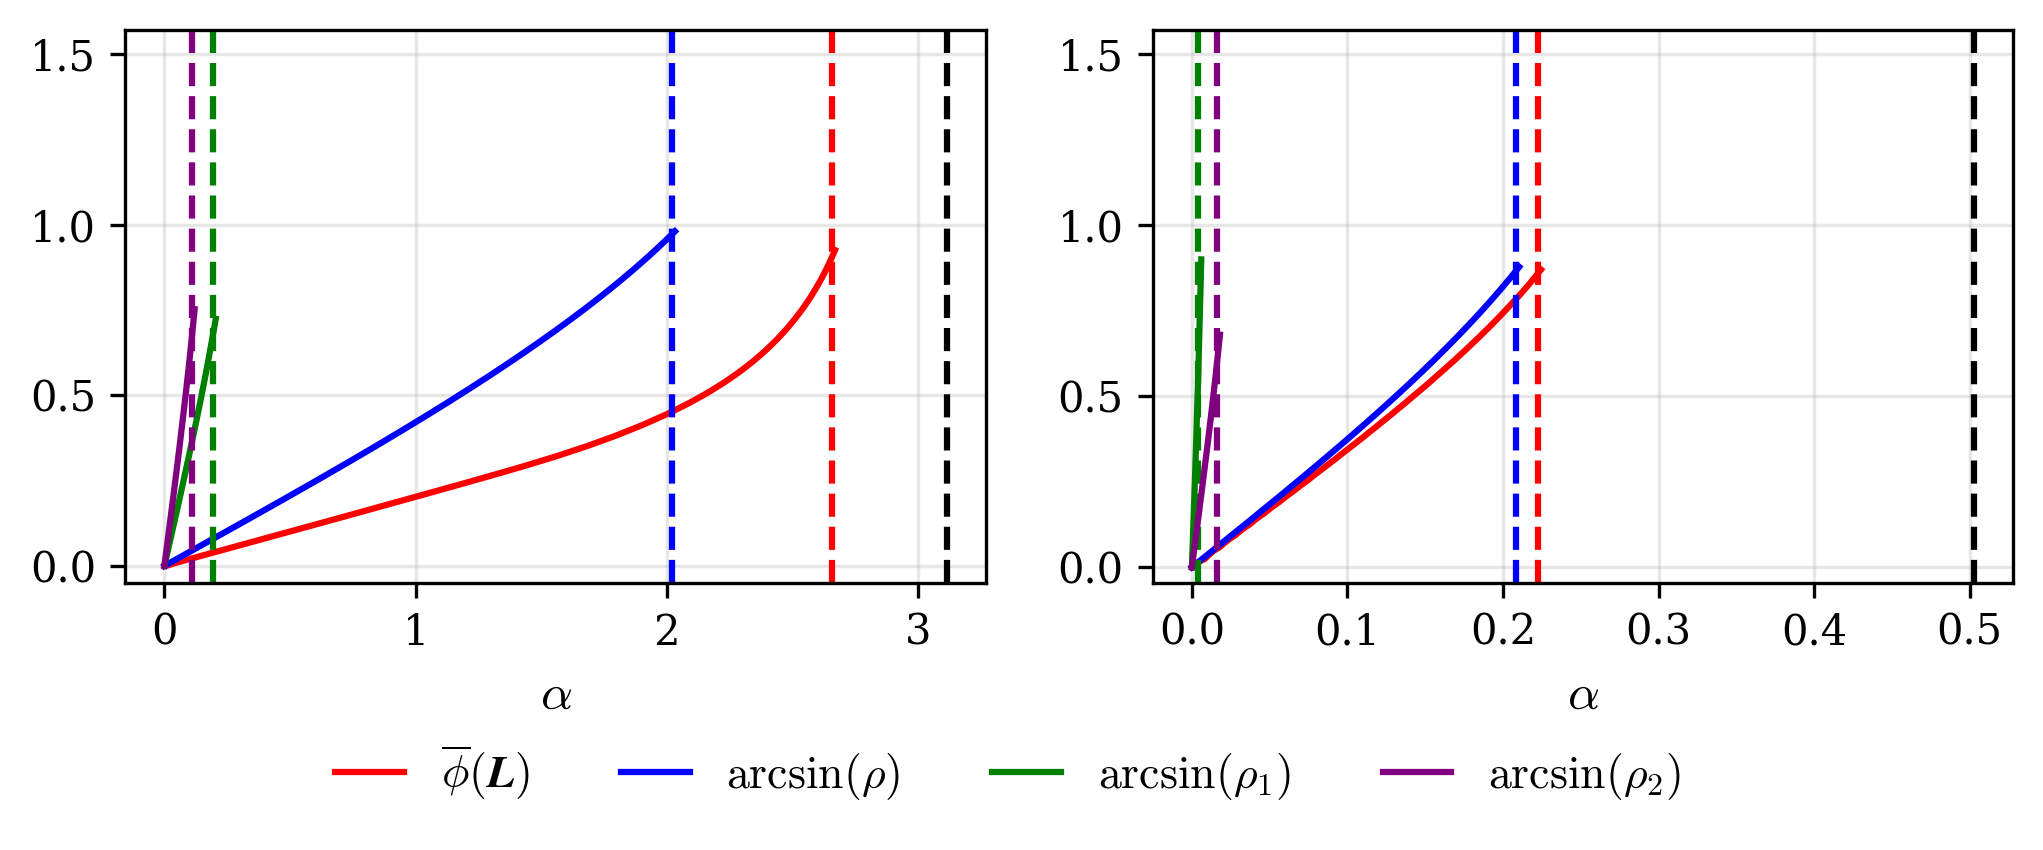

In [175]:
plot_second_two(res_second_ER, res_second_WS)